In [1]:
# Importação das bibliotecas para leitura dos dados e criação de gráficos
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import os
import pyarrow as pa
import pyarrow.parquet as pq

# Configurando pandas para mostrar todas as linhas e colunas
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

# Configurando pandas para não mostrar notação científica para números
pd.set_option('display.float_format', lambda x: '%.2f' % x)

In [2]:
# Caminhos
caminho_csv = '/content/drive/MyDrive/DADOS/MICRODADOS_ENEM_2019.csv'
arquivo_parquet = '/content/drive/MyDrive/DADOS/MICRODADOS_ENEM_2019.parquet'
chunksize = 500000

print("Iniciando conversão em chunks para um único Parquet...")


chunk_iter = pd.read_csv(caminho_csv,
                         sep=';',
                         encoding='latin-1',
                         chunksize=chunksize,
                         low_memory=False)

writer = None

for i, chunk in enumerate(chunk_iter):

    table = pa.Table.from_pandas(chunk, preserve_index=False)

    if writer is None:
        writer = pq.ParquetWriter(arquivo_parquet, table.schema, compression='snappy')
        print(f"Writer criado com schema do chunk 0.")

    writer.write_table(table)
    print(f'Chunk {i} processado e escrito. ({len(chunk)} linhas)')

if writer:
    writer.close()
    print(f'\nConversão concluída! Arquivo salvo em: {arquivo_parquet}')
else:
    print('Nenhum dado foi lido do CSV.')

Iniciando conversão em chunks para um único Parquet...
Writer criado com schema do chunk 0.
Chunk 0 processado e escrito. (500000 linhas)
Chunk 1 processado e escrito. (500000 linhas)
Chunk 2 processado e escrito. (500000 linhas)
Chunk 3 processado e escrito. (500000 linhas)
Chunk 4 processado e escrito. (500000 linhas)
Chunk 5 processado e escrito. (500000 linhas)
Chunk 6 processado e escrito. (500000 linhas)
Chunk 7 processado e escrito. (500000 linhas)
Chunk 8 processado e escrito. (500000 linhas)
Chunk 9 processado e escrito. (500000 linhas)
Chunk 10 processado e escrito. (95171 linhas)

Conversão concluída! Arquivo salvo em: /content/drive/MyDrive/DADOS/MICRODADOS_ENEM_2019.parquet


In [3]:
df_enem = pd.read_parquet(arquivo_parquet)

In [4]:
# Verificando se existem candidatos duplicados (utilizando a chave de 'NU_INSRCRICAO' que é PK)
len(df_enem['NU_INSCRICAO'].unique()) # Qtd de linhas tem que ser igual a quantidade observada no shape

5095171

In [5]:
# OBSERVAÇÃO: CÉLULA SÓ SERÁ NECESSÁRIA SE O PASSO ANTERIOR EVIDENCIAR LINHAS REPETIDAS
# Caso tenha menos linhas únicas do que observadas no shape, quer dizer que existem candidatos repetidos.
# Criando um novo DF sem as linhas duplicadas e pegando a primeira ocorrência do candidato repetido e excluindo as demais
# df_enem_sem_duplicatas = df_enem.drop_duplicates(subset=['NU_INSCRICAO'], keep='first')

In [6]:
# Explorando os tipos de dados das colunas
df_enem.dtypes

,0
NU_INSCRICAO,int64
NU_ANO,int64
TP_FAIXA_ETARIA,int64
TP_SEXO,object
TP_ESTADO_CIVIL,int64
TP_COR_RACA,int64
TP_NACIONALIDADE,int64
TP_ST_CONCLUSAO,int64
TP_ANO_CONCLUIU,int64
TP_ESCOLA,int64


In [7]:
# Armazenando colunas de respostas e gabaritos (para remoção) que não serão levadas em consideração na análise.
# De acordo com o dicionário, essas colunas possuem o prefixo TX
colunas_tx = [coluna for coluna in df_enem.columns if coluna.startswith('TX_')]
colunas_tx

['TX_RESPOSTAS_CN',
 'TX_RESPOSTAS_CH',
 'TX_RESPOSTAS_LC',
 'TX_RESPOSTAS_MT',
 'TX_GABARITO_CN',
 'TX_GABARITO_CH',
 'TX_GABARITO_LC',
 'TX_GABARITO_MT']

In [8]:
# Realizando a mesma coisa com as colunas de código, utilizam o prefixo CO_
colunas_co = [coluna for coluna in df_enem.columns if coluna.startswith('CO_')]
colunas_co

['CO_MUNICIPIO_ESC',
 'CO_UF_ESC',
 'CO_MUNICIPIO_PROVA',
 'CO_UF_PROVA',
 'CO_PROVA_CN',
 'CO_PROVA_CH',
 'CO_PROVA_LC',
 'CO_PROVA_MT']

In [9]:
# Realizando a mesma coisa com colunas de municipios, a análise por municipio é uma granularidade alta por existirem muitos
# municipios, para analisar de uma forma mais macro vamos fazer com os estados.
colunas_municipio = [coluna for coluna in df_enem.columns if 'MUNICIPIO' in coluna]
colunas_municipio

['CO_MUNICIPIO_ESC',
 'NO_MUNICIPIO_ESC',
 'CO_MUNICIPIO_PROVA',
 'NO_MUNICIPIO_PROVA']

In [10]:
# Removendo colunas
colunas_remover = colunas_tx + colunas_co + colunas_municipio + ['NU_ANO', 'NU_INSCRICAO']
df_enem = df_enem.drop(colunas_remover, axis = 1)

In [11]:
# Verificando a atualização no número de colunas do dataframe
df_enem.shape

(5095171, 56)

In [12]:
# Utilizando o describe para analisar as principais métricas estatísticas (média, desvio padrão, min, máx e etc)
df_enem.describe()

,TP_FAIXA_ETARIA,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ANO_CONCLUIU,TP_ESCOLA,TP_ENSINO,IN_TREINEIRO,TP_DEPENDENCIA_ADM_ESC,TP_LOCALIZACAO_ESC,TP_SIT_FUNC_ESC,TP_PRESENCA_CN,TP_PRESENCA_CH,TP_PRESENCA_LC,TP_PRESENCA_MT,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,TP_LINGUA,TP_STATUS_REDACAO,NU_NOTA_COMP1,NU_NOTA_COMP2,NU_NOTA_COMP3,NU_NOTA_COMP4,NU_NOTA_COMP5,NU_NOTA_REDACAO,Q005
count,5095171.00,5095171.00,5095171.00,5095171.00,5095171.00,5095171.00,5095171.00,2878135.00,5095171.00,1147387.00,1147387.00,1147387.00,5095171.00,5095171.00,5095171.00,5095171.00,3710335.00,3923046.00,3923046.00,3710335.00,5095171.00,3923045.00,3923045.00,3923045.00,3923045.00,3923045.00,3923045.00,3923045.00,5095171.00
mean,5.69,1.08,2.13,1.03,1.54,2.96,1.33,1.00,0.12,2.25,1.04,1.01,0.73,0.77,0.77,0.73,477.82,507.25,520.52,523.12,0.52,1.14,120.48,122.74,114.81,121.63,91.53,571.19,3.87
std,3.99,0.44,1.02,0.21,0.72,4.11,0.55,0.07,0.33,0.75,0.19,0.12,0.45,0.42,0.42,0.45,76.10,82.41,64.15,109.06,0.50,0.79,33.43,42.93,40.18,38.12,59.44,188.76,1.48
min,1.00,0.00,0.00,0.00,1.00,0.00,1.00,1.00,0.00,1.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00
25%,3.00,1.00,1.00,1.00,1.00,0.00,1.00,1.00,0.00,2.00,1.00,1.00,0.00,1.00,1.00,0.00,417.80,447.90,483.50,435.10,0.00,1.00,120.00,120.00,100.00,100.00,40.00,480.00,3.00
50%,4.00,1.00,2.00,1.00,1.00,1.00,1.00,1.00,0.00,2.00,1.00,1.00,1.00,1.00,1.00,1.00,470.30,510.60,526.20,501.10,1.00,1.00,120.00,120.00,120.00,120.00,100.00,580.00,4.00
75%,9.00,1.00,3.00,1.00,2.00,4.00,2.00,1.00,0.00,2.00,1.00,1.00,1.00,1.00,1.00,1.00,533.20,566.60,565.30,597.80,1.00,1.00,140.00,140.00,140.00,140.00,140.00,680.00,5.00
max,20.00,4.00,5.00,4.00,4.00,13.00,3.00,2.00,1.00,4.00,2.00,4.00,2.00,2.00,2.00,2.00,860.90,835.10,801.70,985.50,1.00,9.00,200.00,200.00,200.00,200.00,200.00,1000.00,20.00


In [13]:
# Armazenando todas as colunas que possuem as notas dos candidatos
colunas_notas = [coluna for coluna in df_enem.columns if 'NOTA' in coluna]
colunas_notas

['NU_NOTA_CN',
 'NU_NOTA_CH',
 'NU_NOTA_LC',
 'NU_NOTA_MT',
 'NU_NOTA_COMP1',
 'NU_NOTA_COMP2',
 'NU_NOTA_COMP3',
 'NU_NOTA_COMP4',
 'NU_NOTA_COMP5',
 'NU_NOTA_REDACAO']

In [14]:
# Retirando as colunas de notas que são divididas por competência na nota final da redação, que é apenas o que me interessa.
colunas_notas = [coluna for coluna in colunas_notas if 'COMP' not in coluna]
colunas_notas

['NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT', 'NU_NOTA_REDACAO']

## Analisando as notas com auxílio de boxplot, histplot e gráfico de densidade (kdeplot) para as notas de redação que tem intervalos mais espaçados.

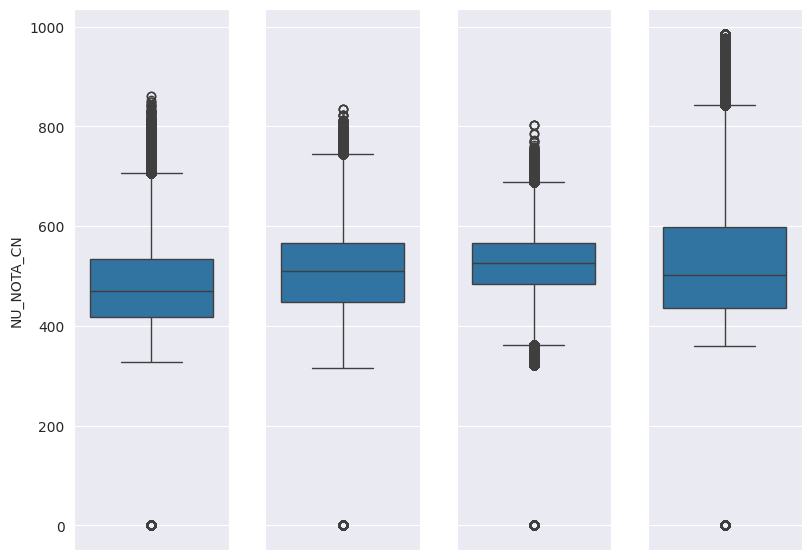

In [15]:
# Análise das notas
sns.set_style("darkgrid")
figura, graficos = plt.subplots(1, 4, sharey = True, figsize = (8,6)) # Padronizando o y máx para os 4 gráficos com sharey True
plt.tight_layout()

for i in range(4):
    coluna_1 = colunas_notas[i]
    sns.boxplot(data = df_enem, y = coluna_1, ax = graficos[i])

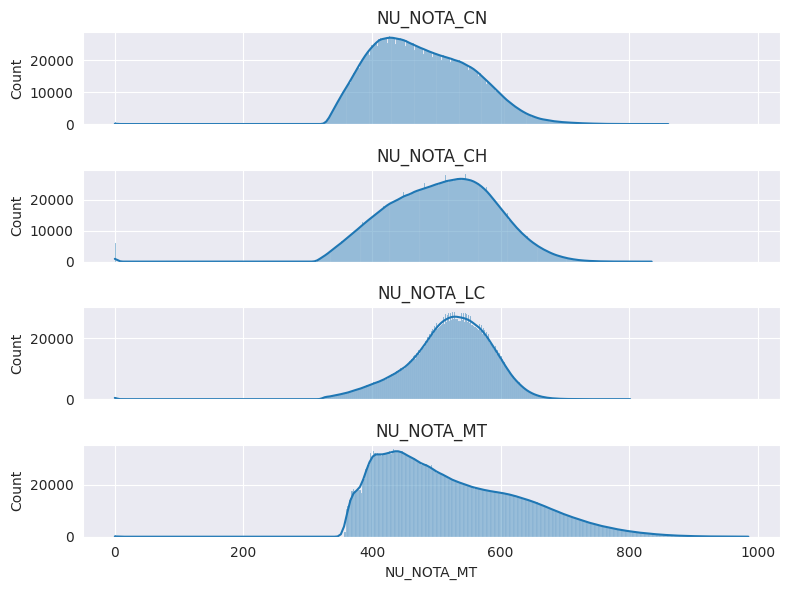

In [16]:
# Analisando as ditribuições das notas
sns.set_style("darkgrid")
figura, graficos = plt.subplots(4, 1, sharex = True, figsize = (8,6))

for i in range(4):
    coluna_1 = colunas_notas[i]
    sns.histplot(data = df_enem[coluna_1], ax = graficos[i], kde = True)
    graficos[i].set_title(coluna_1)

plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'NU_NOTA_REDACAO')

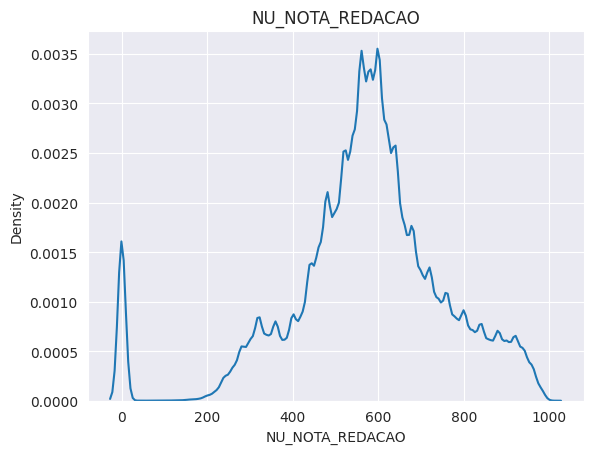

In [17]:
# Analisando a nota de redação
sns.kdeplot(data = df_enem['NU_NOTA_REDACAO']).set_title('NU_NOTA_REDACAO')

## Analisando as informações demográficas.

In [18]:
# Reinicializando os índices
df_enem = df_enem.reset_index(drop = True)

In [19]:
# Percentual dos candidatos divididos por sexo
df_enem['TP_SEXO'].value_counts(normalize = True) * 100

,proportion
TP_SEXO,
F,59.50
M,40.50


<Axes: xlabel='TP_SEXO', ylabel='count'>

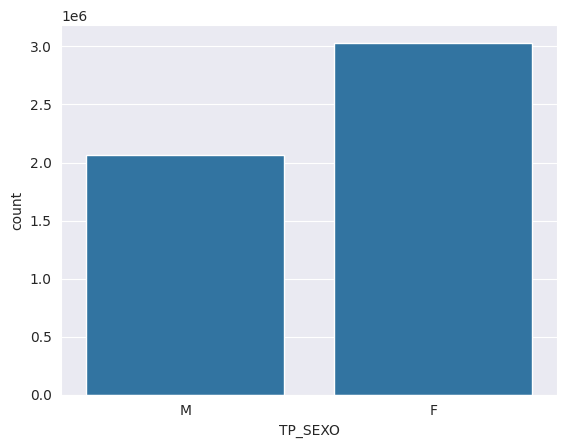

In [20]:
# Plotando esse percentual em contagem
sns.countplot(data = df_enem, x = 'TP_SEXO')

In [21]:
# Realizando contagem das raças dos alunos e ordenando pelo índice
'''
0 - Não declarado
1 - Branca
2 - Preta
3 - Parda
4 - Amarela
5 - Indígena
'''
df_enem['TP_COR_RACA'].value_counts().sort_index()

,count
TP_COR_RACA,
0,103199
1,1831750
2,648298
3,2364011
4,116157
5,31756


<Axes: xlabel='TP_COR_RACA', ylabel='count'>

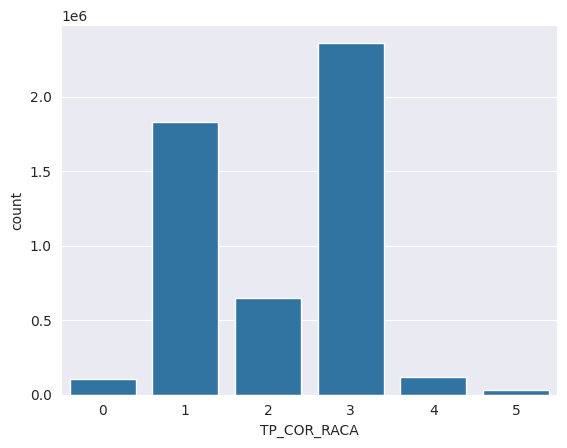

In [22]:
# Plotando o gráfico de raça dos candidatos
sns.countplot(data = df_enem, x = 'TP_COR_RACA')

In [23]:
# Candidatos por região/estado (Aplicação da prova)
uf = df_enem['SG_UF_PROVA'].value_counts()

In [24]:
# Criando dataframe de candidados por estado, utilizando os estados como índice. (Aplicação da prova)
df_uf = pd.DataFrame({'uf': uf.index, 'candidatos': uf.values})
df_uf.head()

,uf,candidatos
0,SP,815990
1,MG,534625
2,BA,395427
3,RJ,339716
4,CE,294984


In [25]:
# Plotando treemap para visualizar a quantidade de candidatos por estado (Aplicação da prova)
import plotly.express as px

fig = px.treemap(data_frame = df_uf,
                path = ['uf'],
                values = 'candidatos')
fig.update_traces(root_color = "lightgrey")
fig.update_layout(margin = dict(t = 50, l = 25, r = 25, b = 25))
fig.show()

In [26]:
# Até que série seu pai, ou o homem responsável por você, estudou?
'''
A - Nunca estudou
B - Não completou a 4ª série do EF.
C - Completou a 4ª série, mas não completou a 8ª série do EF.
D - Completou 8ª série do EF, mas não completou o EM.
E - Completou o EM, mas não completou a Faculdade.
F - Completou a faculdade, mas não completou a pós-graduação
G - Completou a Pós-Graduação
H - Não sei
'''
df_enem['Q001'].value_counts().sort_index()

,count
Q001,
A,290612
B,1135800
C,723504
D,586610
E,1308970
F,375707
G,229177
H,444791


In [27]:
# Avaliando o impacto nos dados daqueles que responderam não sei
proporcao = len(df_enem.loc[df_enem['Q001'] == 'H']) / df_enem.shape[0]
print(f"A proporção de pessoas que responderam 'Não sei' é de: {proporcao * 100:.2f}%")

A proporção de pessoas que responderam 'Não sei' é de: 8.73%


In [28]:
# Até que série sua mãe, ou a responsável por você, estudou?
df_enem['Q002'].value_counts().sort_index()

,count
Q002,
A,194620
B,854819
C,686182
D,667400
E,1633666
F,513696
G,399459
H,145329


In [29]:
# Avaliando o impacto nos dados daqueles que responderam não sei
proporcao = len(df_enem.loc[df_enem['Q002'] == 'H']) / df_enem.shape[0]
print(f"A proporção de pessoas que responderam 'Não sei' é de: {proporcao * 100:.2f}%")

A proporção de pessoas que responderam 'Não sei' é de: 2.85%


In [30]:
# Criando variáveis para delimitar pais que possuem nível superior
df_enem['pai_possui_superior'] = df_enem['Q001'].isin(['F', 'G'])
df_enem['mae_possui_superior'] = df_enem['Q002'].isin(['F', 'G'])
df_enem.head()

,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ANO_CONCLUIU,TP_ESCOLA,TP_ENSINO,IN_TREINEIRO,SG_UF_ESC,TP_DEPENDENCIA_ADM_ESC,TP_LOCALIZACAO_ESC,TP_SIT_FUNC_ESC,SG_UF_PROVA,TP_PRESENCA_CN,TP_PRESENCA_CH,TP_PRESENCA_LC,TP_PRESENCA_MT,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,TP_LINGUA,TP_STATUS_REDACAO,NU_NOTA_COMP1,NU_NOTA_COMP2,NU_NOTA_COMP3,NU_NOTA_COMP4,NU_NOTA_COMP5,NU_NOTA_REDACAO,Q001,Q002,Q003,Q004,Q005,Q006,Q007,Q008,Q009,Q010,Q011,Q012,Q013,Q014,Q015,Q016,Q017,Q018,Q019,Q020,Q021,Q022,Q023,Q024,Q025,pai_possui_superior,mae_possui_superior
0,13,M,1,3,1,1,11,1,NaN,0,None,NaN,NaN,NaN,SP,0,0,0,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,B,B,A,A,2,A,A,B,C,A,A,B,A,A,A,A,A,A,A,A,A,C,A,C,B,False,False
1,8,M,1,1,1,1,5,1,1.00,0,None,NaN,NaN,NaN,BA,0,0,0,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,C,E,B,B,4,C,A,B,C,A,A,B,A,A,A,A,A,A,B,A,A,E,A,A,B,False,False
2,13,F,1,3,1,1,13,1,1.00,0,None,NaN,NaN,NaN,CE,0,0,0,0,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,E,E,B,C,2,B,A,B,B,A,A,B,A,A,A,A,A,A,B,A,A,C,A,A,B,False,False
3,10,F,1,1,1,1,4,1,NaN,0,None,NaN,NaN,NaN,TO,1,1,1,1,483.80,503.60,537.30,392.00,1,1.00,120.00,120.00,120.00,100.00,0.00,460.00,C,E,B,D,4,E,A,C,C,A,B,B,A,B,A,A,A,A,C,A,B,D,A,B,B,False,False
4,7,F,1,1,1,1,4,1,1.00,0,None,NaN,NaN,NaN,MG,1,1,1,1,513.60,575.50,570.70,677.00,0,1.00,160.00,120.00,180.00,200.00,200.00,860.00,E,E,C,C,3,G,A,C,D,B,A,B,B,B,A,B,A,A,B,A,A,C,B,B,B,False,False


In [31]:
# Comparação em porcentagem de quantos candidatos possuem pai que possui o ES completo vs que não possuem
df_enem['pai_possui_superior'].value_counts(normalize = True) * 100

,proportion
pai_possui_superior,
False,88.13
True,11.87


<Axes: xlabel='pai_possui_superior', ylabel='count'>

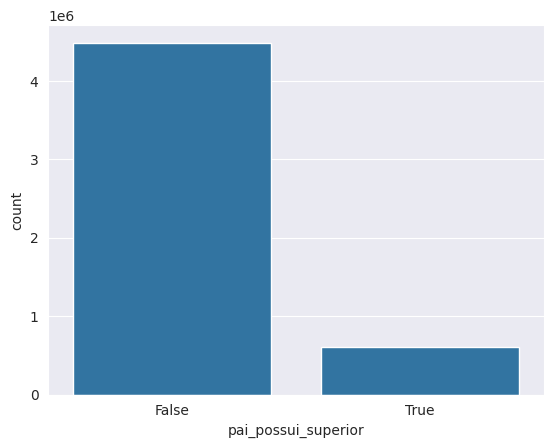

In [32]:
# Até que série seu pai, ou o homem responsável por você, estudou?
sns.countplot(data = df_enem, x = 'pai_possui_superior')

In [33]:
# Comparação em porcentagem de quantos candidatos possuem mãe que possui o ES completo vs que não possuem
df_enem['mae_possui_superior'].value_counts(normalize = True) * 100

,proportion
mae_possui_superior,
False,82.08
True,17.92


<Axes: xlabel='mae_possui_superior', ylabel='count'>

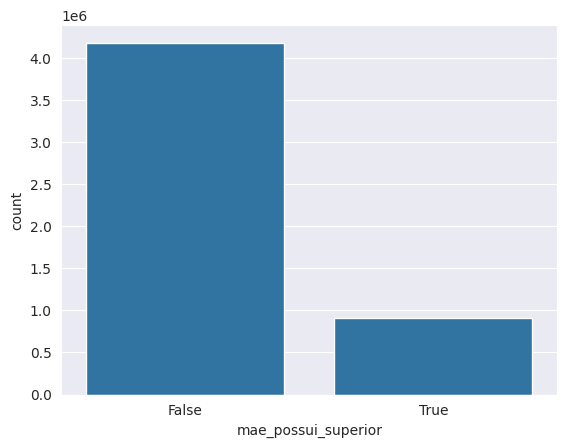

In [34]:
# Até que série sua mãe, ou a responsável por você, estudou?
sns.countplot(data = df_enem, x = 'mae_possui_superior')

In [35]:
# Análise da renda familiar
'''
A Nenhuma renda.
B Até R$ 998,00.
C De R$ 998,01 até R$ 1.497,00.
D De R$ 1.497,01 até R$ 1.996,00.
E De R$ 1.996,01 até R$ 2.495,00.
F De R$ 2.495,01 até R$ 2.994,00.
G De R$ 2.994,01 até R$ 3.992,00.
H De R$ 3.992,01 até R$ 4.990,00.
I De R$ 4.990,01 até R$ 5.988,00.
J De R$ 5.988,01 até R$ 6.986,00.
K De R$ 6.986,01 até R$ 7.984,00.
L De R$ 7.984,01 até R$ 8.982,00.
M De R$ 8.982,01 até R$ 9.980,00.
N De R$ 9.980,01 até R$ 11.976,00.
O De R$ 11.976,01 até R$ 14.970,00.
P De R$ 14.970,01 até R$ 19.960,00.
Q Mais de R$ 19.960,00.
'''

# Transformando essas faixas categóricas em tipo numérico
# Importando ascii_uppercase para fazer iteração sobre o alfabeto
from string import ascii_uppercase

dicionario_renda = dict()

for i, letra in enumerate(ascii_uppercase):
    if i == 17:
        break
    dicionario_renda[letra] = i

# Função de mapeamento
df_enem['renda_familiar'] = df_enem['Q006'].map(dicionario_renda)
df_enem.head()

,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ANO_CONCLUIU,TP_ESCOLA,TP_ENSINO,IN_TREINEIRO,SG_UF_ESC,TP_DEPENDENCIA_ADM_ESC,TP_LOCALIZACAO_ESC,TP_SIT_FUNC_ESC,SG_UF_PROVA,TP_PRESENCA_CN,TP_PRESENCA_CH,TP_PRESENCA_LC,TP_PRESENCA_MT,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,TP_LINGUA,TP_STATUS_REDACAO,NU_NOTA_COMP1,NU_NOTA_COMP2,NU_NOTA_COMP3,NU_NOTA_COMP4,NU_NOTA_COMP5,NU_NOTA_REDACAO,Q001,Q002,Q003,Q004,Q005,Q006,Q007,Q008,Q009,Q010,Q011,Q012,Q013,Q014,Q015,Q016,Q017,Q018,Q019,Q020,Q021,Q022,Q023,Q024,Q025,pai_possui_superior,mae_possui_superior,renda_familiar
0,13,M,1,3,1,1,11,1,NaN,0,None,NaN,NaN,NaN,SP,0,0,0,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,B,B,A,A,2,A,A,B,C,A,A,B,A,A,A,A,A,A,A,A,A,C,A,C,B,False,False,0
1,8,M,1,1,1,1,5,1,1.00,0,None,NaN,NaN,NaN,BA,0,0,0,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,C,E,B,B,4,C,A,B,C,A,A,B,A,A,A,A,A,A,B,A,A,E,A,A,B,False,False,2
2,13,F,1,3,1,1,13,1,1.00,0,None,NaN,NaN,NaN,CE,0,0,0,0,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,E,E,B,C,2,B,A,B,B,A,A,B,A,A,A,A,A,A,B,A,A,C,A,A,B,False,False,1
3,10,F,1,1,1,1,4,1,NaN,0,None,NaN,NaN,NaN,TO,1,1,1,1,483.80,503.60,537.30,392.00,1,1.00,120.00,120.00,120.00,100.00,0.00,460.00,C,E,B,D,4,E,A,C,C,A,B,B,A,B,A,A,A,A,C,A,B,D,A,B,B,False,False,4
4,7,F,1,1,1,1,4,1,1.00,0,None,NaN,NaN,NaN,MG,1,1,1,1,513.60,575.50,570.70,677.00,0,1.00,160.00,120.00,180.00,200.00,200.00,860.00,E,E,C,C,3,G,A,C,D,B,A,B,B,B,A,B,A,A,B,A,A,C,B,B,B,False,False,6


<Axes: xlabel='renda_familiar', ylabel='count'>

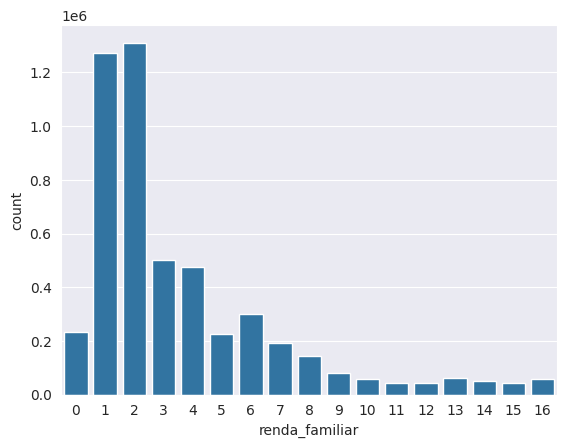

In [36]:
# Plotando renda familiar dos candidatos
sns.countplot(data = df_enem, x = 'renda_familiar')

### Análise de como as notas dos candidatos são influenciadas pelos fatores abaixo:

- Sexo
- Raça
- Atendimento Especial
- Instrução mãe e pai
- Renda mensal da família

In [37]:
# Criando dataframe com as notas e sexos dos candidatos
df_sexo = df_enem.loc[:, colunas_notas + ['TP_SEXO']] # ':' utilizado para pega todas as linhas do dataframe enem
df_sexo.head()

,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,NU_NOTA_REDACAO,TP_SEXO
0,NaN,NaN,NaN,NaN,NaN,M
1,NaN,NaN,NaN,NaN,NaN,M
2,NaN,NaN,NaN,NaN,NaN,F
3,483.80,503.60,537.30,392.00,460.00,F
4,513.60,575.50,570.70,677.00,860.00,F


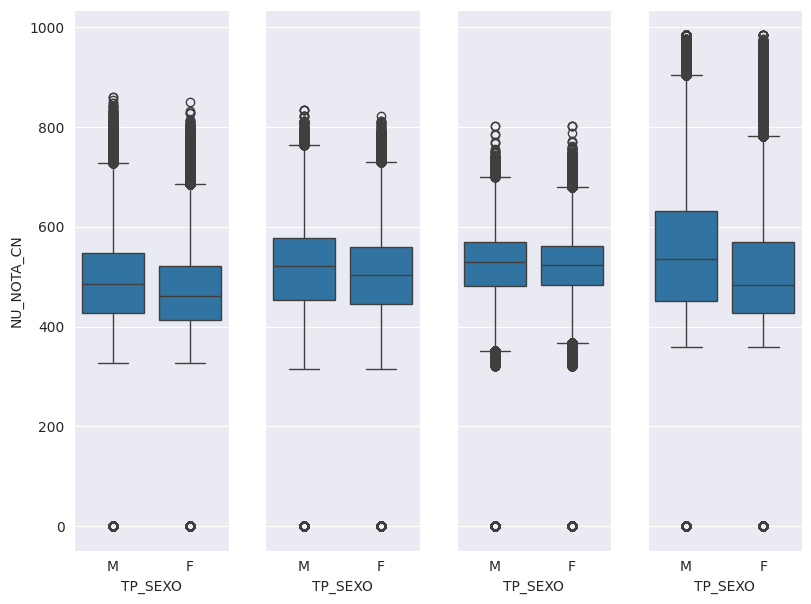

In [38]:
# Analisando notas por sexo realizando um boxplot
sns.set_style("darkgrid")
figura, graficos = plt.subplots(1, 4, sharey = True, figsize = (8,6))
plt.tight_layout()

for i in range(4):
    coluna_1 = colunas_notas[i]
    sns.boxplot(data = df_sexo, y = coluna_1, x = 'TP_SEXO', ax = graficos[i])

In [39]:
# Criando dataframe com as notas por raça dos candidatos
df_raca = df_enem.loc[:, colunas_notas + ['TP_COR_RACA']] #
df_raca.head()

,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,NU_NOTA_REDACAO,TP_COR_RACA
0,NaN,NaN,NaN,NaN,NaN,3
1,NaN,NaN,NaN,NaN,NaN,1
2,NaN,NaN,NaN,NaN,NaN,3
3,483.80,503.60,537.30,392.00,460.00,1
4,513.60,575.50,570.70,677.00,860.00,1


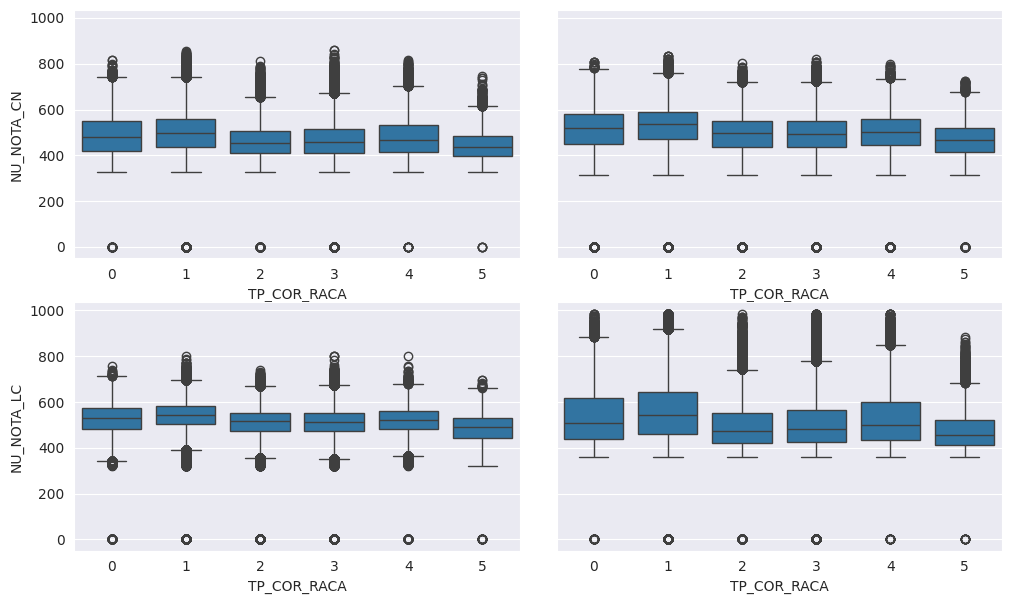

In [40]:
# Analisando as notas por raça fazendo um boxplot
sns.set_style("darkgrid")
figura, graficos = plt.subplots(2,2, sharey = True, figsize = (10,6))
plt.tight_layout()

for i in range(2):
    coluna_1 = colunas_notas[i*2]
    coluna_2 = colunas_notas[i*2+1]
    sns.boxplot(data = df_raca, y = coluna_1, x = 'TP_COR_RACA', ax = graficos[i][0])
    sns.boxplot(data = df_raca, y = coluna_2, x = 'TP_COR_RACA', ax = graficos[i][1])

In [41]:
# Criação de dataframe com as notas e níveis de instrução de pai e mãe
df_instrucao_pais = df_enem.loc[:, colunas_notas + ['pai_possui_superior', 'mae_possui_superior']]

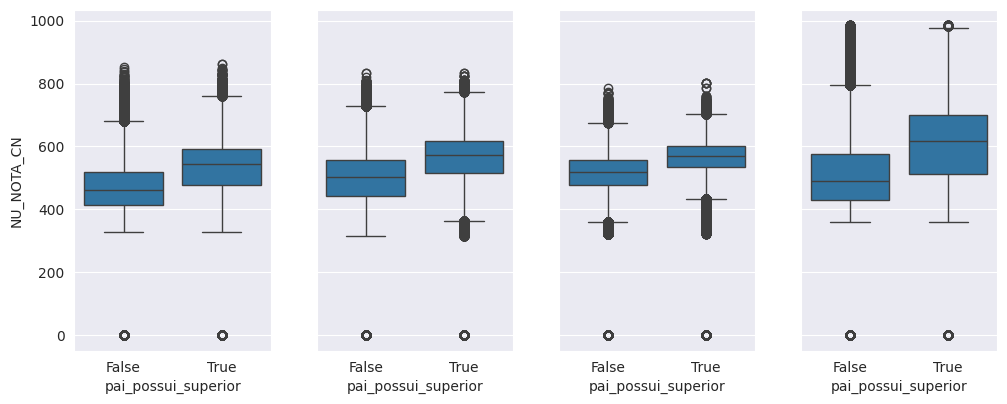

In [42]:
# Analisando notas por instrução do pai
sns.set_style("darkgrid")
figura, graficos = plt.subplots(1, 4, sharey = True, figsize = (10,4))
plt.tight_layout()

for i in range(4):
    coluna_1 = colunas_notas[i]
    sns.boxplot(data = df_instrucao_pais, y = coluna_1, x = 'pai_possui_superior', ax = graficos[i])

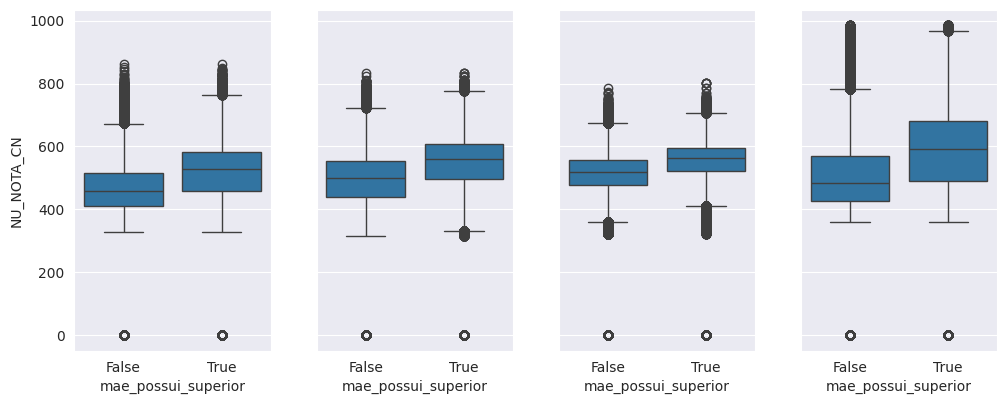

In [43]:
# Analisando notas por instrução da mãe
sns.set_style("darkgrid")
figura, graficos = plt.subplots(1, 4, sharey = True, figsize = (10,4))
plt.tight_layout()

for i in range(4):
    coluna_1 = colunas_notas[i]
    sns.boxplot(data = df_instrucao_pais, y = coluna_1, x = 'mae_possui_superior', ax = graficos[i])

In [44]:
# Criação do dataframe de notas por renda, para posteriormente criar um heatmap para analisar a existência ou não de correlação
df_renda = df_enem.loc[:, colunas_notas + ['renda_familiar']]

<Axes: >

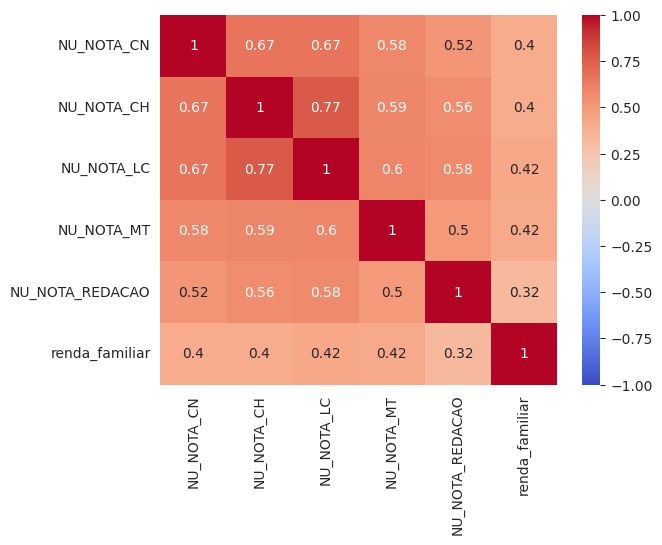

In [45]:
# Analisando correlação de pearson entre as notas e a renda familiar (depois analisar se é melhor utilizar a correlação de
# pearson ou correlação de spearmanr())
correlacoes_renda = df_renda.corr(method='spearman')
sns.heatmap(correlacoes_renda, annot=True, cmap='coolwarm', vmin=-1, vmax=1)